### 논문 따라서 constrative learning 따라하기...
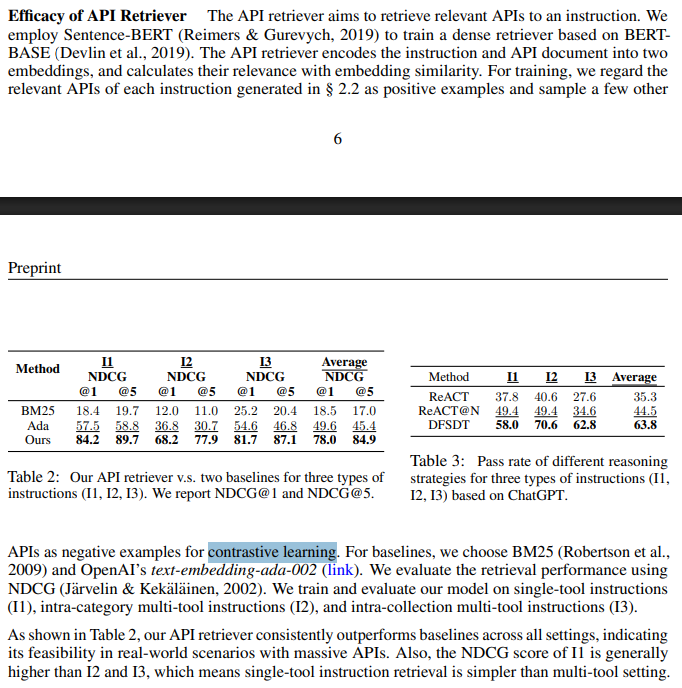  
https://arxiv.org/pdf/2307.16789

# 1. data 만들기

In [5]:
import pandas as pd
import random
import json

# 1. CSV 로드
df = pd.read_csv("C:\\Users\\AMLPC03\\deepseers\\ragTest\\res\\0203\\trainf.csv", encoding="utf-8-sig")

# 2. subCategory별 문서(설명) 생성
# 여기서는 간단히 "subCategory + 설명"으로 만듦
subCategory_docs = {}
with open("category_discription.json", "r", encoding="utf-8") as f:
    subCategory_docs = json.load(f)  # JSON에서 바로 로드

# 3. 학습 데이터 만들기 (instruction ↔ positive/negative)
train_data = []

for idx, row in df.iterrows():
    instruction = row['text']
    pos_doc = subCategory_docs[row['subCategory']]  # positive 문서
    
    # negative는 다른 subCategory에서 랜덤 선택
    neg_subs = [s for s in subCategory_docs.keys() if s != row['subCategory']]
    neg_docs = random.sample([subCategory_docs[s] for s in neg_subs], k=min(3, len(neg_subs)))
    
    train_data.append({
        "instruction": instruction,  # 텍스트
        "positive": pos_doc,  # 정답 카테고리
        "negative": neg_docs  # 오답 카테고리
    })

# 4. JSONL로 저장
with open("constrative_train.jsonl", "w", encoding="utf-8") as f:
    for item in train_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"총 {len(train_data)}개의 학습 샘플 생성 완료!")


총 441개의 학습 샘플 생성 완료!


# 2. 학습
Base: KoE5나 BERT 계열(Sentence-BERT) 사용

Objective: Contrastive Learning (예: InfoNCE / Triplet Loss)

Input: instruction ↔ 문서

Output: embedding 벡터
→ instruction embedding과 문서 embedding이 가까워지도록 학습

In [16]:
import sys
!{sys.executable} - m pip install datasets accelerate

^C


In [17]:
try:
    import datasets
    import accelerate
    print("설정 완료! 이제 학습을 시작할 수 있습니다.")
except ImportError as e:
    print(f"아직 설치가 안 됐어요: {e}")

설정 완료! 이제 학습을 시작할 수 있습니다.


In [19]:
import pandas as pd
import json
import random
from datasets import Dataset  # <--- 이 줄이 '무조건' 있어야 합니다!
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

# ... 그 아래는 재민 님이 짠 코드 그대로 ...

# 1. 데이터 로드
train_examples = []
with open("constrative_train.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        # instruction ↔ positive ↔ negative
        train_examples.append(InputExample(
            texts=[item['instruction'], item['positive']], 
            label=1.0  # positive pair
        ))
        train_examples.append(InputExample(
            texts=[item['instruction'], item['negative']],
            label=0.0  # negative pair
        ))

# 2. 모델 로드 (KoE5 임베딩 가능 모델)
model = SentenceTransformer("nlpai-lab/KoE5")

# 3. DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)

# 4. Loss 정의 (contrastive)
train_loss = losses.CosineSimilarityLoss(model)

# 5. 학습
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,  # 데이터가 적은 450개라 3 epoch이 적절. 데이터를 몇번봤나
    warmup_steps=50,
    output_path="./koe5_dense_retriever"
)


NameError: name 'Dataset' is not defined

위와 같은 오류가 떠서 코드 그대로 복붙해서 py 확장자 파일에서 돌림.  
해당 파일은 지움.   
pip install 후 vs code 껐다 키면 보통 적용됨.   

- 다음에는 train에서 vali랑 test도 빼기... 정석인데 깜빡....
---

# 3. 평가
3-1. test data

- constrative_train.jsonl : train datasets
- koe5_dense_retriever : fine tuning 된 모델 저장 폴더
- 모호질의.csv : test datasets 100개만

In [35]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA available: True
Current device: NVIDIA GeForce RTX 5050


In [42]:
import json
import pandas as pd
import torch
import time
from sentence_transformers import SentenceTransformer, util

# 1. 모델 로드 (학습된 모델!)
model = SentenceTransformer("./koe5_dense_retriever", device="cpu")

# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(100)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# (선택) 실패 케이스 저장
pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.740
Top-3 Accuracy: 0.850
Average Latency: 0.121 seconds per query


---

- first attempt  
Top-1 Accuracy: 0.730 Top-3 Accuracy: 0.840 time: 0.1

- second attempt  
no_function과 roi control collection 설명 약간 수정  
Top-1 Accuracy: 0.740 Top-3 Accuracy: 0.850 time: 0.1


# 4. 분석

In [43]:
df = pd.read_csv('test_result.csv', encoding='utf-8-sig')

onlyFalse = df[df['gt'] != df['pred_top1']]

print(f"Number of false predictions: {len(onlyFalse)}")
onlyFalse

Number of false predictions: 26


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,calibration,"['calibration', 'set_option', 'geometry_set']",0.481369,0.143495
3,inspectRejectMark 버튼 눌러줘,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'no_function', 'insp...",0.469035,0.126920
8,색상 빨간색으로,set_option,system_setting,"['system_setting', 'calibration', 'no_function']",0.890947,0.106720
13,티칭 테스트 버튼 클릭해,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'inspection_execute'...",0.551592,0.115712
22,sawing 외곽선 threshold를 10-60으로 설정,set_threshold,set_parameter,"['set_parameter', 'set_threshold', 'geometry_s...",0.740929,0.147460
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'no_function', 'ui_navigation_e...",0.939489,0.113037
29,LightSave,calibration_set,history_set,"['history_set', 'calibration', 'system_setting']",0.382559,0.105503
40,LGA 필터링 조건 적용,filter_set,system_setting,"['system_setting', 'calibration', 'set_thresho...",0.472246,0.124538
41,BGA 검사 불필요한 기록 제거,filter_set,history_set,"['history_set', 'roi_collection_control', 'set...",0.892306,0.108743
42,LGA ROI 선택 후 필터 적용,filter_set,calibration,"['calibration', 'roi_collection_control', 'set...",0.328424,0.106326


In [44]:
onlyFalse['gt'].value_counts()

gt
roi_collection_control    5
filter_set                4
inspection_execute        3
calibration               3
set_threshold             2
set_size                  2
set_option                1
calibration_set           1
no_function               1
close_windows             1
setting_Preset            1
ui_navigation_execute     1
system_setting            1
Name: count, dtype: int64

In [40]:
import pandas as pd
import ast


def top3_miss(row):
    try:
        top3 = ast.literal_eval(row['pred_top3'])  # 문자열 → 리스트
        return row['gt'] not in top3
    except:
        return True  # 파싱 실패도 실패로 간주

onlyCompletelyWrong = onlyFalse[onlyFalse.apply(top3_miss, axis=1)]
print(f"Number of completely wrong predictions: {len(onlyCompletelyWrong)}")

onlyCompletelyWrong


Number of completely wrong predictions: 15


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,calibration,"['calibration', 'set_option', 'geometry_set']",0.481369,0.151863
8,색상 빨간색으로,set_option,system_setting,"['system_setting', 'calibration', 'no_function']",0.890947,0.115739
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'no_function', 'ui_navigation_e...",0.939489,0.097427
29,LightSave,calibration_set,history_set,"['history_set', 'calibration', 'system_setting']",0.382559,0.124064
40,LGA 필터링 조건 적용,filter_set,system_setting,"['system_setting', 'calibration', 'set_thresho...",0.472246,0.111198
41,BGA 검사 불필요한 기록 제거,filter_set,history_set,"['history_set', 'roi_collection_control', 'set...",0.892306,0.118891
42,LGA ROI 선택 후 필터 적용,filter_set,calibration,"['calibration', 'roi_collection_control', 'set...",0.328424,0.118241
43,LGA 필터 적용 후 결과 확인,filter_set,inspection_execute,"['inspection_execute', 'calibration', 'setting...",0.747538,0.104535
81,bga ForeignMaterial 바꿔,ui_navigation_execute,system_setting,"['system_setting', 'calibration', 'roi_collect...",0.890632,0.126516
82,보정(캘리브레이션) 창에서 사이즈 설정,calibration,set_size,"['set_size', 'open_window', 'set_parameter']",0.947972,0.152652


In [32]:
print("전체:", len(df))
print("Top-3 완전 실패:", len(onlyCompletelyWrong))
print("비율:", len(onlyCompletelyWrong) / len(df))


전체: 100
Top-3 완전 실패: 16
비율: 0.16


# 5. 개선 방향
✅ 1순위: description을 “사용자 발화 기준”으로 재작성  
✅ 2순위: 헷갈리는 쌍에만 negative 강화 

재학습을 위해 데이터 수정.   
부정 질의를 유사한 것 위주로 추가  
소량 데이터 29개  
이후에도 안좋은면 propetyname도 넣을 예정

---

# 6-1. 두번째 학습
- 데이터 만들기

In [ ]:
import json

INPUT_PATH = "constrative_train.jsonl"
OUTPUT_PATH = "contrastive_train_confusion_only.jsonl"

CONFUSION_MAP = {
    "roi_collection_control": [
        "roi_geometry_set",
        "set_size",
        "set_threshold"
    ],
    "filter_set": [
        "set_option",
        "system_setting",
        "inspection_execute"
    ],
    "inspection_execute": [
        "calibration",
        "ui_navigation_execute"
    ]
}

CATEGORY_DESCRIPTION = {
    "roi_collection_control": "ROI 집합에 대해 추가, 삭제 또는 초기화 동작을 수행합니다.",
    "roi_geometry_set": "ROI의 위치나 좌표, 영역 범위를 숫자로 지정합니다.",
    "set_size": "검사 대상의 크기 최소 또는 최대 값을 설정합니다.",
    "set_threshold": "검사 대상이 명확히 구분되도록 임계값을 설정합니다.",

    "filter_set": "검사 기록에서 데이터 필터링 조건을 설정합니다.",
    "set_option": "검사 대상이나 패키지의 옵션을 변경합니다.",
    "system_setting": "장비의 시스템 전반 설정을 변경합니다.",
    "inspection_execute": "검사 또는 티칭 테스트를 실행하고 결과를 반환합니다.",

    "calibration": "장비 보정 관련 파라미터를 조정합니다.",
    "ui_navigation_execute": "UI에서 특정 탭이나 화면으로 이동합니다."
}

In [ ]:
def extract_confusion_only():
    with open(INPUT_PATH, "r", encoding="utf-8") as fin, \
         open(OUTPUT_PATH, "w", encoding="utf-8") as fout:

        for line in fin:
            data = json.loads(line)

            positive_desc = data["positive"]
            category = None
            for k, v in CATEGORY_DESCRIPTION.items():
                if v == positive_desc:
                    category = k
                    break

            # confusion 대상만 별도 저장
            if category in CONFUSION_MAP:
                negatives = set(data.get("negative", []))
                for confused_cat in CONFUSION_MAP[category]:
                    negatives.add(CATEGORY_DESCRIPTION[confused_cat])

                new_sample = {
                    "instruction": data["instruction"],
                    "positive": data["positive"],
                    "negative": list(negatives)
                }

                fout.write(json.dumps(new_sample, ensure_ascii=False) + "\n")

if __name__ == "__main__":
    extract_confusion_only()

- 2 학습 진행

In [1]:
import json
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

# 1. confusion-only 데이터 로드
train_examples = []
with open("contrastive_train_confusion_only.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)

        # positive pair
        train_examples.append(
            InputExample(
                texts=[item["instruction"], item["positive"]],
                label=1.0
            )
        )

        # negative pairs
        for neg_text in item["negative"]:
            train_examples.append(
                InputExample(
                    texts=[item["instruction"], neg_text],
                    label=0.0
                )
            )

print(f"Total confusion training pairs: {len(train_examples)}")

# 2. 기존 학습된 모델 로드 (중요!)
model = SentenceTransformer("./koe5_dense_retriever")

# 3. DataLoader
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=4   # 🔽 소량 데이터라 batch도 줄임
)

# 4. Loss (동일)
train_loss = losses.CosineSimilarityLoss(model)

# 5. 이어서 학습 (짧고 약하게)
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,              # 🔴 confusion-only는 1 epoch 권장
    warmup_steps=5,        # 🔴 거의 안 둠
    output_path="./koe5_dense_retriever_confusion"
)


Total confusion training pairs: 174


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


2번째 재평가

In [8]:
import json
import pandas as pd
import torch
import time
from sentence_transformers import SentenceTransformer, util

# 1. 모델 로드 (학습된 모델!)
model = SentenceTransformer("./koe5_dense_retriever_confusion", device="cpu")

# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(100)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# (선택) 실패 케이스 저장
pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.810
Top-3 Accuracy: 0.910
Average Latency: 0.117 seconds per query



- first attempt  
Top-1 Accuracy: 0.730 Top-3 Accuracy: 0.840 time: 0.1

- second attempt  
no_function과 roi control collection 설명 약간 수정  
Top-1 Accuracy: 0.740 Top-3 Accuracy: 0.850 time: 0.1

- third
부정 답 2개정도 더 추가하여 소량(29) 재학습  
Top-1 Accuracy: 0.780  Top-3 Accuracy: 0.890  Average Latency: 0.116

- forth
라벨링을 잘못한거 더 발견...ㅎㅎ 쏘리... 맞았는데 틀렸다했네...^^  
Top-1 Accuracy: 0.810  Top-3 Accuracy: 0.910  Average Latency: 0.117

- 2번째 분석

In [10]:
df = pd.read_csv('test_result.csv', encoding='utf-8-sig')

onlyFalse = df[df['gt'] != df['pred_top1']]

print(f"Number of false predictions: {len(onlyFalse)}")
onlyFalse

Number of false predictions: 19


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,system_setting,"['system_setting', 'calibration', 'set_option']",0.659677,0.127275
3,inspectRejectMark 버튼 눌러줘,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.476590,0.126090
13,티칭 테스트 버튼 클릭해,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.589339,0.120430
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'set_parameter', 'calibration']",0.946697,0.120589
29,LightSave,calibration_set,history_set,"['history_set', 'calibration', 'roi_collection...",0.387875,0.093216
32,LGA 모델 영역 ROI 생성,geometry_set,roi_collection_control,"['roi_collection_control', 'geometry_set', 'se...",0.465014,0.112475
40,LGA 필터링 조건 적용,history_set,system_setting,"['system_setting', 'calibration', 'change_mode']",0.558386,0.114078
42,LGA 선택 후 필터 적용,history_set,system_setting,"['system_setting', 'calibration', 'roi_collect...",0.348623,0.104226
43,LGA 필터 적용 후 결과 확인,history_set,inspection_execute,"['inspection_execute', 'calibration', 'chat_cl...",0.906489,0.102530
45,어제 본 드라마 결말이 좀 이상했어,no_function,close_windows,"['close_windows', 'no_function', 'chat_clear']",0.760717,0.118448


In [11]:
df = pd.read_csv('C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv', encoding='utf-8-sig')
df['subCategory'].value_counts()

subCategory
roi_collection_control        11
setting_Preset                11
geometry_set                  11
set_threshold                 10
calibration                    6
set_size                       6
change_mode                    5
history_set                    5
close_windows                  4
chat_clear                     4
set_option                     4
auto_configuration_execute     4
system_setting                 4
inspection_execute             4
no_function                    3
ui_navigation_execute          3
set_parameter                  3
calibration_set                1
open_window                    1
Name: count, dtype: int64

# 7. 테스트 데이터 불균형 해소
100 -> 184
- 각 서브 카테고리마다 10개 이상으로 맞춤

In [17]:
model = SentenceTransformer("./koe5_dense_retriever_confusion", device="cpu")

# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(184)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# (선택) 실패 케이스 저장
pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.859
Top-3 Accuracy: 0.940
Average Latency: 0.118 seconds per query


In [25]:
df = pd.read_csv('test_result.csv', encoding='utf-8-sig')

onlyFalse = df[df['gt'] != df['pred_top1']]

print(f"Number of false predictions: {len(onlyFalse)}")
onlyFalse

Number of false predictions: 26


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,system_setting,"['system_setting', 'calibration', 'set_option']",0.659677,0.120997
3,inspectRejectMark 버튼 눌러줘,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.476590,0.132438
13,티칭 테스트 버튼 클릭해,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.589339,0.111018
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'set_parameter', 'calibration']",0.946697,0.097272
29,LightSave,calibration,history_set,"['history_set', 'calibration', 'roi_collection...",0.387875,0.113367
32,LGA 모델 영역 ROI 생성,geometry_set,roi_collection_control,"['roi_collection_control', 'geometry_set', 'se...",0.465014,0.109126
40,LGA 필터링 조건 적용,history_set,system_setting,"['system_setting', 'calibration', 'change_mode']",0.558386,0.119449
42,LGA 선택 후 필터 적용,history_set,system_setting,"['system_setting', 'calibration', 'roi_collect...",0.348623,0.127458
43,LGA 필터 적용 후 결과 확인,history_set,inspection_execute,"['inspection_execute', 'calibration', 'chat_cl...",0.906489,0.092175
45,어제 본 드라마 결말이 좀 이상했어,no_function,close_windows,"['close_windows', 'no_function', 'chat_clear']",0.760717,0.124761


In [26]:
onlyFalse.to_csv('wrong_predictions.csv', index=False, encoding='utf-8-sig')
print("wrong_predictions.csv 파일로 저장 완료!")


wrong_predictions.csv 파일로 저장 완료!


---
# 6-2. 90퍼센트로 올리기 위한 세번째 학습

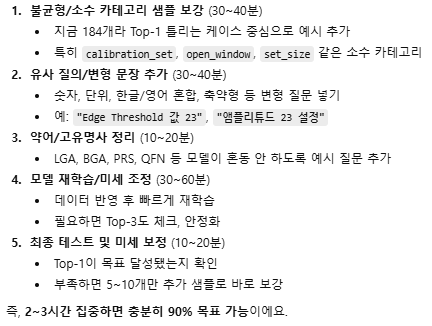  
보강 대작전.
- 최소 목표
top-1 : 0.837 -> 90%  
top-3 : 0.924 -> 95%  
여기까지는 올리자  

In [11]:
df = pd.read_csv('C:\\Users\\AMLPC03\\deepseers\\ragTest\\res\\0203\\train3.csv', encoding='utf-8')
df['subCategory'].value_counts()

subCategory
calibration               7
inspection_execute        6
set_parameter             6
no_function               6
history_set               5
close_windows             2
open_window               2
roi_collection_control    2
set_size                  2
ui_navigation_execute     1
system_setting            1
Name: count, dtype: int64

- 3번째 데이터 생성

In [12]:
import pandas as pd
import random
import json

# 1. CSV 로드
df = pd.read_csv("C:\\Users\\AMLPC03\\deepseers\\ragTest\\res\\0203\\train3.csv", encoding="utf-8-sig")

# 2. subCategory별 문서(설명) 생성
# 여기서는 간단히 "subCategory + 설명"으로 만듦
subCategory_docs = {}
with open("category_discription.json", "r", encoding="utf-8") as f:
    subCategory_docs = json.load(f)  # JSON에서 바로 로드

# 3. 학습 데이터 만들기 (instruction ↔ positive/negative)
train_data = []

for idx, row in df.iterrows():
    instruction = row['text']
    pos_doc = subCategory_docs[row['subCategory']]  # positive 문서
    
    # negative는 다른 subCategory에서 랜덤 선택
    neg_subs = [s for s in subCategory_docs.keys() if s != row['subCategory']]
    neg_docs = random.sample([subCategory_docs[s] for s in neg_subs], k=min(3, len(neg_subs)))
    
    train_data.append({
        "instruction": instruction,  # 텍스트
        "positive": pos_doc,  # 정답 카테고리
        "negative": neg_docs  # 오답 카테고리
    })

# 4. JSONL로 저장
with open("constrative_train_3.jsonl", "w", encoding="utf-8") as f:
    for item in train_data:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"총 {len(train_data)}개의 학습 샘플 생성 완료!")


총 40개의 학습 샘플 생성 완료!


- 3번째 학습

In [13]:
import json
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader, random_split

# ==============================
# 1️⃣ 데이터 로드 & InputExample 생성
# ==============================

train_examples = []

def flatten_negatives(neg):
    """재귀적으로 negative를 모두 문자열 리스트로 변환"""
    if isinstance(neg, str):
        return [neg]
    elif isinstance(neg, list):
        flat = []
        for n in neg:
            flat.extend(flatten_negatives(n))
        return flat
    else:
        # 숫자나 None 등이 들어오는 경우 무시
        return []

with open("constrative_train_3.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        instr = item["instruction"]
        pos = item["positive"]

        # positive pair
        if isinstance(pos, str):
            train_examples.append(InputExample(texts=[instr, pos], label=1.0))

        # negative flatten 처리
        negatives = flatten_negatives(item.get("negative", []))
        for neg in negatives:
            train_examples.append(InputExample(texts=[instr, neg], label=0.0))

print(f"총 training pairs: {len(train_examples)}")


# ==============================
# 2️⃣ 기존 모델 로드 (두 번째로 학습했던 모델)
# ==============================
model = SentenceTransformer("./koe5_dense_retriever_confusion")

# ==============================
# 3️⃣ DataLoader 생성
# ==============================
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=4)

# ==============================
# 4️⃣ Loss 정의
# ==============================
train_loss = losses.CosineSimilarityLoss(model)

# ==============================
# 5️⃣ 학습 (validation 없이, 소량 데이터 최적화)
# ==============================
# 망하게 만듬
# model.fit(
#     train_objectives=[(train_dataloader, train_loss)],
#     epochs=2,                # 소량 데이터라 2 epoch로 Top-1 안정화
#     warmup_steps=5,          
#     evaluator=None,          
#     output_path="./koe5_dense_retriever_confusion2",
#     show_progress_bar=True
# )

model.fit(train_objectives=[(train_dataloader, train_loss)],
    epochs=1,              # 🔴 confusion-only는 1 epoch 권장
    warmup_steps=5,        # 🔴 거의 안 둠
    output_path="./koe5_dense_retriever_confusion_2"
)

print("✅ Confusion-only fine-tuning 완료!")

총 training pairs: 187


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


KeyboardInterrupt: 

### 보통 비율  
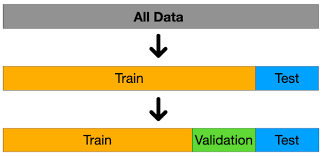

Train : Validation : Test = 70 : 15 : 15

혹은 80 : 10 : 10

In [ ]:
## 담에 데이터가 더 많을 때는 꼭 train, vali, test  나누기
# ==============================
# 2️⃣ 소량 데이터용 train/validation split
# ==============================

# val_ratio = 0.2
# val_size = max(1, int(len(train_examples) * val_ratio))
# train_size = len(train_examples) - val_size
# train_dataset, val_dataset = random_split(train_examples, [train_size, val_size])
# print(f"Train pairs: {len(train_dataset)}, Validation pairs: {len(val_dataset)}")

# # ==============================
# # 3️⃣ 기존 모델 로드
# # ==============================
# model = SentenceTransformer("./koe5_dense_retriever_confusion")   # 두번째로 학습했던 모델

# # ==============================
# # 4️⃣ DataLoader 생성
# # ==============================
# train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=4)
# val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=4)

- 3번째 평가

In [14]:
import json
import pandas as pd
import torch
import time
from sentence_transformers import SentenceTransformer, util

# 1. 모델 로드 (학습된 모델!)
model = SentenceTransformer("./koe5_dense_retriever_confusion_2", device="cpu")

# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(184)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# (선택) 실패 케이스 저장
pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.864
Top-3 Accuracy: 0.946
Average Latency: 0.128 seconds per query


이전 결과 (2번째 학습)   
Top-1 Accuracy: 0.859
Top-3 Accuracy: 0.940
Average Latency: 0.118 seconds per query

3번째  (학습 모델. 오전)  
Top-1 Accuracy: 0.848
Top-3 Accuracy: 0.946
Average Latency: 0.128 seconds per query

3번째 (19분걸려서 에폭 수 늘려서 학습해봤는데 오히려 떨어짐)  
 Top-1 Accuracy: 0.777
Top-3 Accuracy: 0.924
Average Latency: 0.123 seconds per query

3번째  (학습 모델. 저녁. 가장 결과 좋음.)  
Top-1 Accuracy: 0.864
Top-3 Accuracy: 0.946
Average Latency: 0.122 seconds per query

In [ ]:
df = pd.read_csv('test_result.csv', encoding='utf-8-sig')

onlyFalse = df[df['gt'] != df['pred_top1']]

print(f"Number of false predictions: {len(onlyFalse)}")
onlyFalse

Number of false predictions: 25


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,set_option,"['set_option', 'set_parameter', 'calibration']",0.619570,0.145110
22,sawing 외곽선 threshold를 10-60으로 설정,set_threshold,set_parameter,"['set_parameter', 'set_threshold', 'system_set...",0.702455,0.136353
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'set_parameter', 'calibration']",0.848797,0.112866
40,LGA 필터링 조건 적용,history_set,inspection_execute,"['inspection_execute', 'calibration', 'no_func...",0.462126,0.122655
42,LGA 선택 후 필터 적용,history_set,calibration,"['calibration', 'inspection_execute', 'no_func...",0.409919,0.119782
43,LGA 필터 적용 후 결과 확인,history_set,inspection_execute,"['inspection_execute', 'no_function', 'calibra...",0.942568,0.105662
45,어제 본 드라마 결말이 좀 이상했어,no_function,close_windows,"['close_windows', 'no_function', 'calibration']",0.680510,0.125843
48,PRS 결과 기반 재티칭 시작,change_mode,inspection_execute,"['inspection_execute', 'change_mode', 'chat_cl...",0.586928,0.100118
50,PRS 다시 티칭할게,change_mode,inspection_execute,"['inspection_execute', 'change_mode', 'no_func...",0.883425,0.117678
65,패키지 설정 초기화,setting_Preset,roi_collection_control,"['roi_collection_control', 'calibration', 'no_...",0.611567,0.126879


In [ ]:
import pandas as pd
import ast


def top3_miss(row):
    try:
        top3 = ast.literal_eval(row['pred_top3'])  # 문자열 → 리스트
        return row['gt'] not in top3
    except:
        return True  # 파싱 실패도 실패로 간주

onlyCompletelyWrong = onlyFalse[onlyFalse.apply(top3_miss, axis=1)]
print(f"Number of completely wrong predictions: {len(onlyCompletelyWrong)}")

onlyCompletelyWrong   

Number of completely wrong predictions: 10


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
2,패키지 탭 fisrtpin 값 10-50,set_threshold,set_option,"['set_option', 'set_parameter', 'calibration']",0.619570,0.145110
40,LGA 필터링 조건 적용,history_set,inspection_execute,"['inspection_execute', 'calibration', 'no_func...",0.462126,0.122655
42,LGA 선택 후 필터 적용,history_set,calibration,"['calibration', 'inspection_execute', 'no_func...",0.409919,0.119782
43,LGA 필터 적용 후 결과 확인,history_set,inspection_execute,"['inspection_execute', 'no_function', 'calibra...",0.942568,0.105662
65,패키지 설정 초기화,setting_Preset,roi_collection_control,"['roi_collection_control', 'calibration', 'no_...",0.611567,0.126879
81,bga ForeignMaterial 바꿔,ui_navigation_execute,system_setting,"['system_setting', 'calibration', 'set_paramet...",0.663953,0.118224
90,lga Contamination 값 설정해,set_size,system_setting,"['system_setting', 'calibration', 'set_paramet...",0.588634,0.130759
93,bga Ball Min Circularity 퍼센트를 바꿔,system_setting,set_option,"['set_option', 'set_parameter', 'calibration']",0.679101,0.146608
100,보정 화면에서 십자선 타입을 FULLSIZE로 바꿔,calibration,set_option,"['set_option', 'set_parameter', 'system_setting']",0.914576,0.125740
168,Calibration,open_window,calibration,"['calibration', 'inspection_execute', 'no_func...",0.729845,0.110504


---
임계값 확인

In [10]:
import pandas as pd
df = pd.read_csv("test_result.csv", encoding="utf-8-sig")

correct = df[df["gt"] == df["pred_top1"]]["score_top1"]
wrong = df[df["gt"] != df["pred_top1"]]["score_top1"]

print("correct count:", len(correct))
print("Correct mean:", f"{correct.mean():.3f}")
print("Wrong mean:", f"{wrong.mean():.3f}")

print("Correct min:", f"{correct.min():.3f}")
print("Correct 10% quantile:", f"{correct.quantile(0.1):.3f}")
print("Wrong 90% quantile:", f"{wrong.quantile(0.9):.3f}")



correct count: 159
Correct mean: 0.894
Wrong mean: 0.719
Correct min: 0.525
Correct 10% quantile: 0.715
Wrong 90% quantile: 0.902


In [19]:
print(correct[correct > 0.75].count())
159- 132

139


27

## 분석: 
- 그냥 단순히 창 이름만 달랑 쓴거는 bm25가 open_window로 처리하게 하기
- history_set 이 필터링 적용인걸 잘 모르는 것 같음.
- setting_Preset, roi_collection_control 둘다 똑같이 동작에 초기화가 들어가서 헷갈리는 듯. 이건 사람도 헷갈릴만함.
- set option
-----

1. 시맨틱 모호성 (Semantic Ambiguity)
사례 (ID 90, 93): "lga Contamination 값 설정해", "bga Ball Min Circularity 바꿔"

현상: 정답은 system_setting이지만, 모델은 set_size나 set_option으로 판단함.

이유: 사용자가 "값(Value)"이나 "바꿔(Change)"라는 단어를 썼을 때, 모델은 이것이 시스템 설정인지 아니면 일반적인 수치/옵션 변경인지 구분하기 어려워함.

해결책: system_setting 컨셉 설명에 **"패키지(BGA/LGA)의 구체적인 검사 항목 명칭이 포함된 경우"**라는 문구를 강화하여 가중치를 높여야 함.

2. 도메인 키워드 미인지 (Domain Keyword Mismatch)
사례 (ID 100): "십자선 타입을 FULLSIZE로 바꿔"

현상: 정답은 calibration인데, 모델은 set_option을 선택함.

이유: "십자선(Reticle)"이나 "FULLSIZE"라는 단어가 calibration 카테고리뿐만 아니라 일반적인 옵션 설정과도 유사도가 높기 때문임.

해결책: 도메인 특수 용어(십자선, 보정 등)에 대해 BM25 키워드 가중치를 높여서 시맨틱 임베딩의 한계를 보완해야 함.

3. 문맥 파악 오류 (Contextual Error)
사례 (ID 40-43, 168): "LGA 필터링 조건 적용", "Calibration"

현상: 정답은 history_set이나 open_window인데, 모델은 inspection_execute나 calibration 자체로 오인함.

이유: 질문이 너무 짧거나("Calibration"), "적용/확인" 같은 단어가 실행(Execute) 의도와 겹쳐서 발생함.

해결책: 1단계 컨셉 분류 시 **사용자의 행동 동사(열기, 닫기, 적용 등)**에 대한 대조 학습 데이터를 보강하여 '행위'와 '대상'을 명확히 구분시켜야 함.

---

### 1️⃣ Hard Negative / 데이터 강화

* 지금처럼 **유사 정답을 오답으로 추가** → 모델이 혼동되는 케이스 학습
* 짧은 질의, 명사 단독, 장비별 특수 표현 등 **실제 사례 기반 augment**
* 데이터가 적을수록 성능 향상폭 큼

---

### 2️⃣ Embedding 모델 업그레이드

* KoE5 → **대형 KoE5 variant** 또는 **KoE5 + instruction-tuned** 모델
* 의미 구분, 문맥 파악 능력 향상

---

### 3️⃣ Multi-Stage RAG

* 현재: Category 후보 → action.json 검색
* 개선: **Top-k 후보 재랭킹 단계 추가**

  * 후보 10~20개 → Cross-Encoder나 Matching 모델로 재정렬
  * 의미 + 장비 도메인 특화 반영

---

### 4️⃣ Prompt/Query Expansion

* 질의가 짧거나 단어 단독일 때, **자동 확장 / Synonym 추가**
* 예: `Calibration` → `Calibration 화면 열기`, `Calibration 설정 변경`
* 모델이 문맥을 더 잘 이해하게 됨

---

### 5️⃣ Ensemble / Voting

* 여러 embedding 모델 또는 여러 RAG candidate scorer를 사용
* Top-k 후보를 **투표/가중치 합산** 후 최종 선택
* 단일 모델보다 Top-1/Top-3 안정성 상승

---

💡 요약:

* 데이터 강화 + hard negative
* 모델 업그레이드 / multi-stage reranking
* 질의 확장 + 앙상블

이 조합이면 **Top-1 ≥ 90%, Top-3 ≥ 95%** 목표에 충분히 접근 가능해요.

----
2️⃣ 간단한 재랭킹 방법 (하루~이틀 가능)
① Cosine similarity 기반 재정렬

Step 1에서 얻은 Top-k 후보 벡터와 질의 벡터를 다시 비교

Cosine similarity 점수로 다시 정렬

② Domain-specific Keyword Boost

후보 중 중요 키워드 포함 여부로 점수 조정

예: 질의에 “Calibration”이 있으면, 후보 중 Calibration 관련 명령 점수 +α

③ 간단한 모델 기반 re-score

작은 Cross-Encoder 모델 (예: KoE5 mini)로

(질의, 후보 문장) → relevance 점수 계산

Top-k 후보 순서 재조정

---
아래 코드는 전혀 학습이 안된 모델 koe5 로 제로샷 테스트 돌려봤을 때

In [ ]:
import json
import pandas as pd
import torch
import time
from sentence_transformers import SentenceTransformer, util

# 1. 모델 로드 (학습 안돤 모델!)
model = SentenceTransformer("nlpai-lab/KoE5")


# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(184)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# # (선택) 실패 케이스 저장
# pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.603
Top-3 Accuracy: 0.815
Average Latency: 0.022 seconds per query


# bm25 사용

In [82]:
import json
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

# ==============================
# 0️⃣ 설정
# ==============================
INPUT_PATH = "constrative_train_3.jsonl"
OUTPUT_PATH = "constrative_train_4.jsonl"

CONFUSION_MAP = {
    "roi_collection_control": ["roi_geometry_set", "set_size", "set_threshold"],
    "history_set": ["set_option", "system_setting", "inspection_execute"],
    "inspection_execute": ["calibration", "ui_navigation_execute"]
}

CATEGORY_DESCRIPTION = {
    "roi_collection_control": "ROI 집합에 대해 추가, 삭제 또는 초기화 동작을 수행합니다.",
    "roi_geometry_set": "ROI의 위치나 좌표, 영역 범위를 숫자로 지정합니다.",
    "set_size": "검사 대상의 크기 최소 최대 값을 설정합니다.",
    "set_threshold": "검사 대상이 명확히 구분되도록 임계값을 설정합니다.",
    "history_set": "검사 기록에서 데이터 필터링 조건을 설정합니다.",
    "set_option": "패키지나 핀 등의 설정 옵션을 변경합니다. 예: Edge 방향, Edge 모드, 첫 번째 핀 타입, 회전각도.",
    "system_setting": "장비의 시스템 설정을 조정합니다. 예: 레시피 파라미터, 저장 옵션, 기능 활성/비활성화, 색상 변경. 가로·세로 길이 설정 등",
    "inspection_execute": "검사 또는 티칭 테스트를 실행하고 결과를 반환합니다.",
    "calibration": "장비 보정 관련 파라미터를 조정합니다.",
    "ui_navigation_execute": "UI에서 특정 탭이나 화면으로 이동합니다."
}

# ==============================
# 1️⃣ confusion-only dataset 생성
# ==============================
def extract_confusion_only():
    with open(INPUT_PATH, "r", encoding="utf-8") as fin, \
         open(OUTPUT_PATH, "w", encoding="utf-8") as fout:

        for line in fin:
            data = json.loads(line)

            positive_desc = data["positive"]
            category = None
            for k, v in CATEGORY_DESCRIPTION.items():
                if v == positive_desc:
                    category = k
                    break

            if category in CONFUSION_MAP:
                # 🔴 여기 중요
                negatives = set(flatten_negatives(data.get("negative", [])))

                for confused_cat in CONFUSION_MAP[category]:
                    negatives.add(CATEGORY_DESCRIPTION[confused_cat])

                new_sample = {
                    "instruction": data["instruction"],
                    "positive": data["positive"],
                    "negative": list(negatives)
                }

                fout.write(json.dumps(new_sample, ensure_ascii=False) + "\n")


extract_confusion_only()

# ==============================
# 2️⃣ InputExample 생성
# ==============================
def flatten_negatives(neg):
    if isinstance(neg, str):
        return [neg]
    elif isinstance(neg, list):
        flat = []
        for n in neg:
            flat.extend(flatten_negatives(n))
        return flat
    else:
        return []

train_examples = []
with open(OUTPUT_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        instr = item["instruction"]
        pos = item["positive"]
        train_examples.append(InputExample(texts=[instr, pos], label=1.0))
        for neg in flatten_negatives(item.get("negative", [])):
            train_examples.append(InputExample(texts=[instr, neg], label=0.0))

print(f"총 training pairs: {len(train_examples)}")

# ==============================
# 3️⃣ 모델 로드 + DataLoader
# ==============================
model = SentenceTransformer("./koe5_dense_retriever_confusion")
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=4)
train_loss = losses.CosineSimilarityLoss(model)

# ==============================
# 4️⃣ 안전 fine-tuning
# ==============================
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=2,            # 소량 데이터라 2 epoch
    warmup_steps=5,
    output_path="./koe5_dense_retriever_confusion_4",
    show_progress_bar=True
)

print("✅ Confusion-only safe fine-tuning 완료!")


총 training pairs: 41


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


✅ Confusion-only safe fine-tuning 완료!


In [ ]:
model = SentenceTransformer("./koe5_dense_retriever_confusion", device="cpu")

# 2. subCategory description 로드
with open("category_discription.json", "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# description embedding (한 번만)
desc_embeddings = model.encode(
    descriptions, 
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 3. 테스트 데이터 로드 (앞 100개만)
df = pd.read_csv(
    r"C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv"
).head(184)

correct_top1 = 0
correct_top3 = 0
results = []

# 4. 테스트 루프
total_time = 0.0  # 전체 시간 누적

for _, row in df.iterrows():
    query = row["text"]
    gt = row["subCategory"]

    start_time = time.time()  # ⏱ 시작

    query_emb = model.encode(
        query, 
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=3)

    end_time = time.time()  # ⏱ 종료
    elapsed_time = end_time - start_time
    total_time += elapsed_time

    pred_top1 = sub_categories[topk.indices[0]]
    pred_top3 = [sub_categories[i] for i in topk.indices.tolist()]

    if pred_top1 == gt:
        correct_top1 += 1
    if gt in pred_top3:
        correct_top3 += 1

    results.append({
        "query": query,
        "gt": gt,
        "pred_top1": pred_top1,
        "pred_top3": pred_top3,
        "score_top1": float(topk.values[0]),
        "latency_sec": elapsed_time   # ✅ 쿼리당 시간
    })


# 5. 결과 출력
n = len(df)
print(f"Top-1 Accuracy: {correct_top1 / n:.3f}")
print(f"Top-3 Accuracy: {correct_top3 / n:.3f}")
print(f"Average Latency: {total_time / n:.3f} seconds per query")

# (선택) 실패 케이스 저장
pd.DataFrame(results).to_csv("test_result.csv", index=False, encoding="utf-8-sig")


Top-1 Accuracy: 0.842
Top-3 Accuracy: 0.935
Average Latency: 0.128 seconds per query


Top-1 Accuracy: 0.783
Top-3 Accuracy: 0.924
Average Latency: 0.128 seconds per query

In [89]:
test_result = pd.read_csv('test_result.csv', encoding='utf-8-sig')
onlyFalse = test_result[test_result['gt'] != test_result['pred_top1']]
print(f"Number of false predictions: {len(onlyFalse)}")
onlyFalse

Number of false predictions: 29


,query,gt,pred_top1,pred_top3,score_top1,latency_sec
0,십자선 기본으로 바꿔줘,calibration,system_setting,"['system_setting', 'calibration', 'set_option']",0.713221,0.111135
2,패키지 탭 fisrtpin 값 10-50,set_threshold,system_setting,"['system_setting', 'calibration', 'set_option']",0.765010,0.139369
3,inspectRejectMark 버튼 눌러줘,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.476590,0.131499
13,티칭 테스트 버튼 클릭해,inspection_execute,ui_navigation_execute,"['ui_navigation_execute', 'roi_collection_cont...",0.589339,0.110675
28,십자선 타입을 fullsize,calibration,set_option,"['set_option', 'system_setting', 'set_parameter']",0.946697,0.104436
29,LightSave,calibration,history_set,"['history_set', 'calibration', 'roi_collection...",0.387875,0.112670
32,LGA 모델 영역 ROI 생성,geometry_set,roi_collection_control,"['roi_collection_control', 'geometry_set', 'se...",0.465014,0.117275
40,LGA 필터링 조건 적용,history_set,system_setting,"['system_setting', 'calibration', 'change_mode']",0.499214,0.129983
42,LGA 선택 후 필터 적용,history_set,system_setting,"['system_setting', 'calibration', 'roi_collect...",0.382135,0.120699
43,LGA 필터 적용 후 결과 확인,history_set,inspection_execute,"['inspection_execute', 'calibration', 'chat_cl...",0.906489,0.111296


In [2]:
from rank_bm25 import BM25Okapi

documents = []

with open("C:\\Users\\AMLPC03\\deepseers\\ragTest\\action.json", "r", encoding="utf-8") as f:
    concepts = json.load(f)

for api in concepts:
    content = (
        f"{api.get('category','')} "
        f"{api.get('description','')} "
        f"{api.get('useCase','')}"
    )
    documents.append(content.split())  # 🔥 토큰 리스트여야 함

bm25 = BM25Okapi(documents)

In [3]:
import json
import pandas as pd
from rank_bm25 import BM25Okapi
from konlpy.tag import Okt

okt = Okt()

def tokenize(text):
    return okt.morphs(text)

# -----------------------------
# Rule-based guardrail
# -----------------------------
SET_PARAMETER_KEYWORDS = [
    "앰플리튜드", "Amplitude",
    "Edge", "Edge Threshold",
    "Outline", "Outline Width", "에지"
]

def is_set_parameter_query(text: str) -> bool:
    text_lower = text.lower()
    return any(k.lower() in text_lower for k in SET_PARAMETER_KEYWORDS)

# -----------------------------
# Threshold
# -----------------------------
BM25_THRESHOLD = 0.8

# -----------------------------
# Data load
# -----------------------------
test_df = pd.read_csv(
    'C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv',
    encoding='utf-8-sig'
).head(184)

results = []

# -----------------------------
# Main routing loop
# -----------------------------
for query in test_df["text"]:

    # 1️⃣ Rule-based (강제 set_parameter)
    if is_set_parameter_query(query):
        results.append({
            "query": query,
            "predicted_concept": "set_parameter",
            "score": 1.0,
            "source": "rule"
        })
        continue

    # 2️⃣ BM25
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)

    top_idx = scores.argmax()
    top_score = float(scores[top_idx])
    top_api = concepts[top_idx]["api_name"]

    if top_score >= BM25_THRESHOLD:
        results.append({
            "query": query,
            "predicted_concept": top_api,
            "score": round(top_score, 4),
            "source": "bm25"
        })
        continue

    # 3️⃣ Dense Retriever (koe5)
    dense_result = koe5_dense_retriever_confusion(query)
    # ↑ 이 함수는 {api_name, score} 반환한다고 가정

    results.append({
        "query": query,
        "predicted_concept": dense_result["api_name"],
        "score": dense_result.get("score", None),
        "source": "dense_retriever"
    })

# -----------------------------
# Save result
# -----------------------------
result_df = pd.DataFrame(results)
result_df.to_csv("hybrid_routing_result.csv", index=False, encoding="utf-8-sig")

print("Hybrid routing 완료 → hybrid_routing_result.csv 생성")


NameError: name 'koe5_dense_retriever_confusion' is not defined

In [11]:
import json
import torch
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("nlpai-lab/KoE5")

category_description_path = "category_discription.json"
embedding_save_path = "desc_embeddings.pt"
meta_save_path = "desc_meta.json"

# subCategory description 로드
with open(category_description_path, "r", encoding="utf-8") as f:
    category_desc = json.load(f)

descriptions = []
sub_categories = []

for k, v in category_desc.items():
    if isinstance(v, list):
        v = " ".join(v)
    sub_categories.append(k)
    descriptions.append(v)

# 🔥 description embedding (딱 1번)
desc_embeddings = model.encode(
    descriptions,
    convert_to_tensor=True,
    normalize_embeddings=True
)

# 저장
torch.save(desc_embeddings, embedding_save_path)

with open(meta_save_path, "w", encoding="utf-8") as f:
    json.dump(sub_categories, f, ensure_ascii=False, indent=2)

print("✅ description embedding 저장 완료")

✅ description embedding 저장 완료


In [44]:
import torch
from sentence_transformers import util

# model = SentenceTransformer("./koe5_dense_retriever_confusion", device="cpu")

def rag_inference_single(
    query: str,
    model,
    desc_embeddings,
    sub_categories,
    top_k: int = 3
):
    """
    단일 query에 대한 dense retriever 추론

    Returns
    -------
    pred_top1 : str
        가장 유사한 subCategory
    score_top1 : float
        cosine similarity score
    pred_topk : list[str]
        top-k subCategory 목록
    """

    query_emb = model.encode(
        query,
        convert_to_tensor=True,
        normalize_embeddings=True
    )

    scores = util.cos_sim(query_emb, desc_embeddings)[0]
    topk = torch.topk(scores, k=top_k)

    pred_top1 = sub_categories[topk.indices[0]]
    pred_topk = [sub_categories[i] for i in topk.indices.tolist()]
    score_top1 = float(topk.values[0])

    return pred_top1, score_top1, pred_topk


In [47]:
import pandas as pd

# ===============================
# 1️⃣ Rule-based keyword guard
# ===============================
SET_PARAMETER_KEYWORDS = [
    "앰플리튜드", "Amplitude", 
    "Outline", "Outline Width"
]

def is_set_parameter_query(text: str) -> bool:
    text_lower = text.lower()
    return any(k.lower() in text_lower for k in SET_PARAMETER_KEYWORDS)


# ===============================
# 3️⃣ Inference Pipeline
# ===============================
test_df = pd.read_csv(
    "C:\\Users\\AMLPC03\\deepseers\\ragTest\\testData\\모호질의.csv",
    encoding="utf-8-sig"
).head(184)

results = []
model = SentenceTransformer("koe5_dense_retriever_confusion", device="cpu")
desc_embeddings = torch.load(
    r"C:\Users\AMLPC03\deepseers\ragTest\res\0203\constrativeLearning\desc_embeddings.pt",
    map_location="cpu"
)


for _, row in test_df.iterrows():
    query = row["query"] if "query" in row else row["text"]
    gt = row.get("gt", None)

    # 1️⃣ Rule-based (확정)
    if is_set_parameter_query(query):
        pred = "set_parameter"
        score = 1.0
        source = "rule"
    else:
        pred, score, _ = rag_inference_single(
            query,
            model,
            desc_embeddings,
            sub_categories
        )
        source = "rag"


    results.append({
        "query": query,
        "gt": gt,
        "pred": pred,
        "score": score,
        "source": source
    })


result_df = pd.DataFrame(results)
result_df.to_csv("rule_plus_rag_result.csv", index=False, encoding="utf-8-sig")

print("✅ Rule → RAG 실험 완료 (rule_plus_rag_result.csv 생성)")



✅ Rule → RAG 실험 완료 (rule_plus_rag_result.csv 생성)


In [48]:
import pandas as pd

test = pd.read_csv("rule_plus_rag_result.csv", encoding="utf-8-sig")
ans = pd.read_csv(
    r"C:\Users\AMLPC03\deepseers\ragTest\testData\모호질의.csv",
    encoding="utf-8-sig"
)

merged = pd.merge(
    test,
    ans,
    left_on="query",
    right_on="text",
    how="inner"
)

acc = (merged["pred"] == merged["subCategory"]).mean()
print(f"Accuracy: {acc:.3f}")


Accuracy: 0.805
